#Taller Arboles



*  Juan David Ramirez
*  Juan Diego carreño



## 1 Importacion de datos

In [112]:
import pandas as pd

In [113]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "parulpandey/palmer-archipelago-antarctica-penguin-data",
    "penguins_size.csv"
)

df.head()

Using Colab cache for faster access to the 'palmer-archipelago-antarctica-penguin-data' dataset.


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [114]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


##2. Verificacion calidad de los datos

In [115]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

No hay aparentes nulos

In [116]:
df = df.dropna()

In [117]:
df["species"].value_counts()


,count
species,
Adelie,146
Gentoo,120
Chinstrap,68


In [118]:
df["sex"].value_counts()

,count
sex,
MALE,168
FEMALE,165
.,1


Hay que eliminar el valor malo

In [119]:
# Sobreescribe el dataframe manteniendo solo lo que NO sea un punto
df = df[df['sex'] != '.']

In [120]:
df["sex"].value_counts()

,count
sex,
MALE,168
FEMALE,165


In [121]:
df["island"].value_counts()

,count
island,
Biscoe,163
Dream,123
Torgersen,47


##3. Definición de variable objetivo

In [122]:
X = df.drop("species", axis=1)
y = df["species"]

Queremos predecir la especie de un pinguino a partir de sus caracteristicas fisicas

##4. División del dataset

In [123]:
X = pd.get_dummies(df, drop_first=True)

In [124]:
y.head()

,species
0,Adelie
1,Adelie
2,Adelie
4,Adelie
5,Adelie


In [125]:
X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,False,False,True,True
1,39.5,17.4,186.0,3800.0,False,False,False,True,False
2,40.3,18.0,195.0,3250.0,False,False,False,True,False
4,36.7,19.3,193.0,3450.0,False,False,False,True,False
5,39.3,20.6,190.0,3650.0,False,False,False,True,True


Train y Test

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Validacion y test

In [127]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

70% train

15% validation

15% test

##5. Entrenamiento del árbol

In [128]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

##6. Predicción

In [129]:
y_pred = model.predict(X_val)

##7. Evaluación del modelo

In [130]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, y_pred)

1.0

In [131]:
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        22
   Chinstrap       1.00      1.00      1.00        12
      Gentoo       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



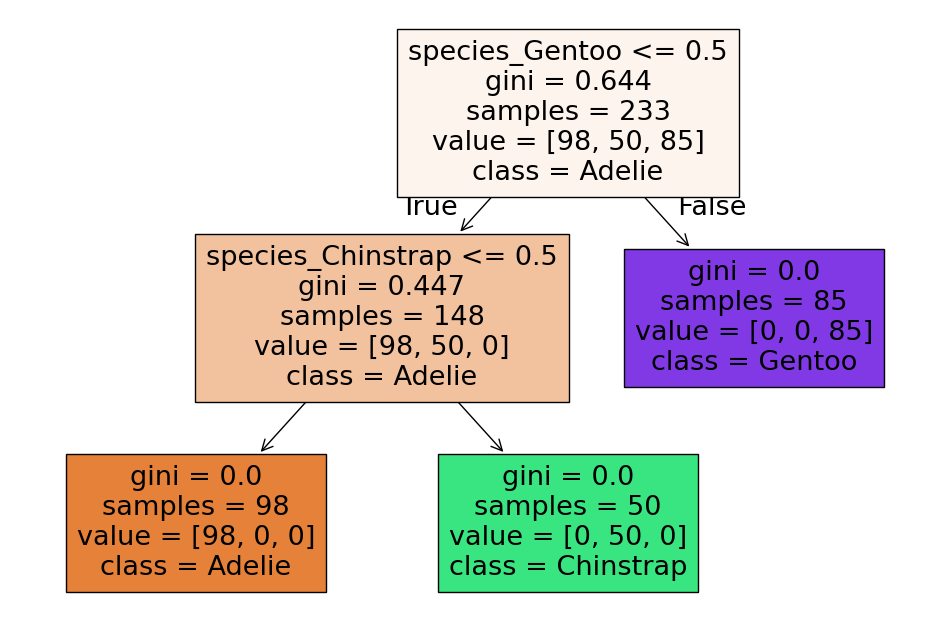

In [132]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.show()

##9.Evaluación final en Test

In [135]:
y_test_pred = model.predict(X_test)

accuracy_score(y_test, y_test_pred)

1.0

##10. Analisis de resultados

Vamos a Ver las Razone spor la cual el modelo clasifica perfectamente

### a) Correlacion entre predictoras y respuesta

In [137]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# copiar dataset
df_corr = df.copy()

# convertir species a números
le = LabelEncoder()
df_corr["species_encoded"] = le.fit_transform(df_corr["species"])

# calcular correlaciones
corr = df_corr.corr(numeric_only=True)

# mostrar correlación con la variable objetivo
print(corr["species_encoded"].sort_values(ascending=False))

species_encoded      1.000000
flipper_length_mm    0.850737
body_mass_g          0.750434
culmen_length_mm     0.730548
culmen_depth_mm     -0.740346
Name: species_encoded, dtype: float64


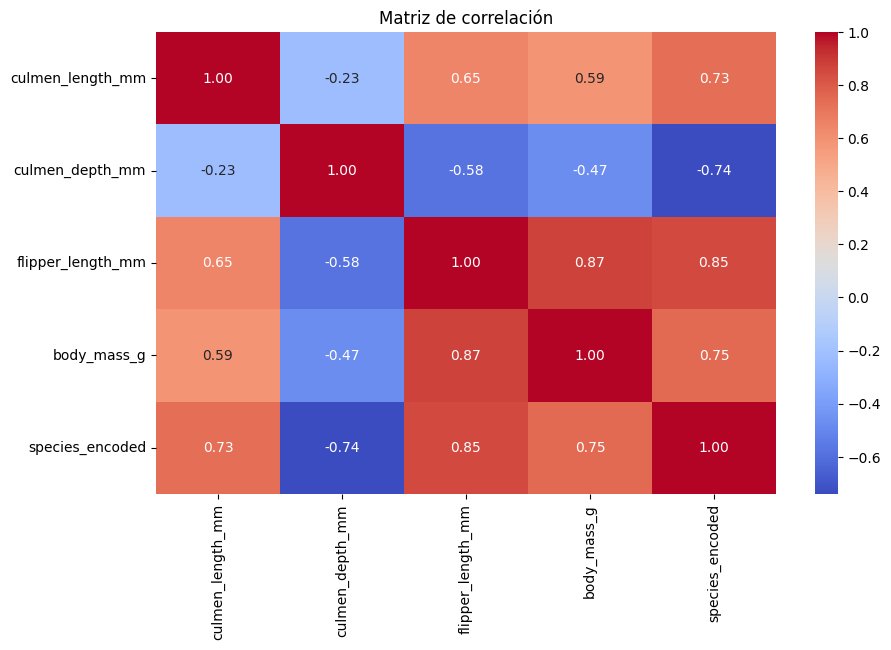

In [138]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación")
plt.show()

###b) Caracteristicas fisicas diferenciables

In [139]:
df.groupby("species")[[
    "flipper_length_mm",
    "body_mass_g",
    "culmen_length_mm",
    "culmen_depth_mm"
]].mean()

,flipper_length_mm,body_mass_g,culmen_length_mm,culmen_depth_mm
species,,,,
Adelie,190.102740,3706.164384,38.823973,18.347260
Chinstrap,195.823529,3733.088235,48.833824,18.420588
Gentoo,217.235294,5092.436975,47.568067,14.996639


In [140]:
df.groupby("species")[[
    "flipper_length_mm",
    "body_mass_g",
    "culmen_length_mm",
    "culmen_depth_mm"
]].agg(["mean","std"])

flipper_length_mm            body_mass_g              \
                       mean       std         mean         std   
species                                                          
Adelie           190.102740  6.521825  3706.164384  458.620135   
Chinstrap        195.823529  7.131894  3733.088235  384.335081   
Gentoo           217.235294  6.585431  5092.436975  501.476154   

          culmen_length_mm           culmen_depth_mm            
                      mean       std            mean       std  
species                                                         
Adelie           38.823973  2.662597       18.347260  1.219338  
Chinstrap        48.833824  3.339256       18.420588  1.135395  
Gentoo           47.568067  3.106116       14.996639  0.985998

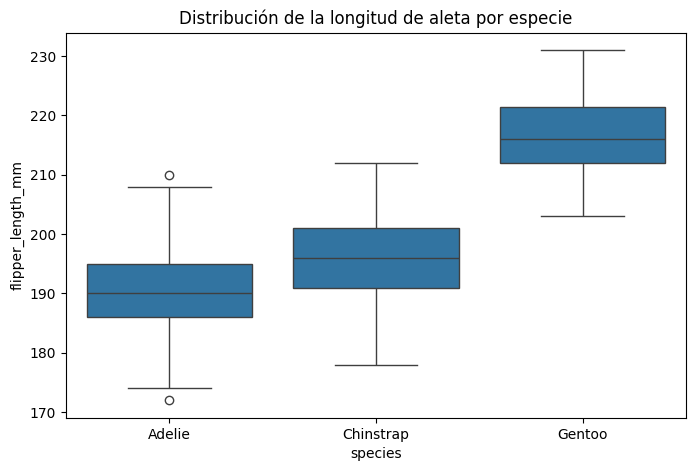

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="species",
    y="flipper_length_mm",
    data=df
)

plt.title("Distribución de la longitud de aleta por especie")
plt.show()

Se ve como claramente los grupos son a simplevista diferenciables, esto nos indicaria aun con mas fuerza la razon de la exacgtitud global del modelo

##11. Conclusion Final

El modelo de árbol de decisión entrenado presenta una exactitud (accuracy) de 1.0 tanto en el conjunto de entrenamiento como en el conjunto de prueba. Este resultado indica que el modelo logra clasificar correctamente todas las observaciones del dataset en sus respectivas especies de pingüinos.

En principio, un resultado perfecto podría sugerir la presencia de overfitting, es decir, que el modelo haya aprendido de memoria los datos de entrenamiento sin capacidad de generalización. Sin embargo, en este caso existen varios elementos que permiten argumentar que el resultado es razonable y no necesariamente producto de sobreajuste.

En primer lugar, se realizó una división adecuada del dataset en conjuntos de entrenamiento y prueba, por lo que la evaluación del modelo se realizó sobre datos que no fueron utilizados durante el entrenamiento.

En segundo lugar, el análisis de correlación entre la variable objetivo (species) y las variables predictoras muestra relaciones muy fuertes. En particular, variables como:

flipper_length_mm presenta una correlación aproximada de 0.85

body_mass_g presenta una correlación aproximada de 0.75

culmen_length_mm presenta una correlación aproximada de 0.73

culmen_depth_mm presenta una correlación negativa fuerte cercana a -0.74

Estas correlaciones indican que las características morfológicas de los pingüinos tienen una alta capacidad discriminativa entre especies. Es decir, las especies presentan diferencias físicas claras que permiten separarlas con relativa facilidad utilizando reglas simples, lo cual es precisamente el tipo de patrón que los árboles de decisión pueden capturar eficazmente.

El análisis de las medias por especie muestra diferencias claras en variables morfológicas como la longitud de la aleta (flipper_length_mm) y la masa corporal (body_mass_g). En particular, la especie Gentoo presenta valores significativamente mayores en longitud de aleta y masa corporal en comparación con las otras especies. Estas diferencias estructurales entre grupos facilitan que el árbol de decisión encuentre reglas de separación claras entre las clases.

Por lo tanto, la alta exactitud obtenida no necesariamente implica sobreajuste, sino que puede explicarse por la fuerte relación existente entre las variables predictoras y la variable objetivo, así como por la estructura del dataset, en el cual las especies de pingüinos presentan diferencias morfológicas marcadas.

En conclusión, el modelo de árbol de decisión logra capturar correctamente los patrones presentes en los datos y clasificar de forma precisa las especies de pingüinos a partir de sus características físicas.